This code creates a spatial mask to define lat/lon locations that are defined as "monsoonal" (True) or "non-monsoonal" (False).

In [ ]:
# import functions
# OS interaction and time
import os
import sys
import cftime
import datetime
import time
import glob
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar
from dask.distributed import Client
import calendar
import importlib

# math and data
import math
import numpy as np
import netCDF4 as nc
import xarray as xr
from functools import partial
import scipy as sp
import scipy.linalg
from scipy.signal import detrend
import pandas as pd
import pickle as pickle
from sklearn import linear_model
import matplotlib.patches as mpatches
from shapely.geometry.polygon import LinearRing
import statsmodels.stats.multitest as multitest

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm

from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.axes_divider import HBoxDivider
import mpl_toolkits.axes_grid1.axes_size as Size
from mpl_toolkits.axes_grid1 import make_axes_locatable

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

# random
from IPython.display import display
from IPython.display import HTML
import IPython.core.display as di # Example: di.display_html('<h3>%s:</h3>' % str, raw=True)

# paths to various directories
rda_era5_path = '/glade/campaign/collections/rda/data/ds633.0/'  # base path to ERA5 data on derecho
my_era5_path = '/glade/u/home/zcleveland/scratch/ERA5/'  # path to subset data
misc_data_path = '/glade/u/home/zcleveland/scratch/misc_data/'  # path to misc data
plot_out_path = '/glade/u/home/zcleveland/NAM_soil-moisture/ERA5_analysis/plots/'  # path to generated plots
scripts_main_path = '/glade/u/home/zcleveland/NAM_soil-moisture/scripts_main/'  # path to my dicts, lists, and functions

# import variable lists and dictionaries
if scripts_main_path not in sys.path:
    sys.path.insert(0, scripts_main_path)  # path to file containing these lists/dicts
if 'get_var_data' in sys.modules:
    importlib.reload(sys.modules['get_var_data'])
if 'my_functions' in sys.modules:
    importlib.reload(sys.modules['my_functions'])
if 'my_dictionaries' in sys.modules:
    importlib.reload(sys.modules['my_dictionaries'])

# import common functions that I've created
from get_var_data import get_var_data, get_var_files, open_var_data, subset_var_data, time_to_year_month_avg, time_to_year_month_sum, time_to_year_month
from my_functions import month_num_to_name, ensure_var_list

# import lists and dictionaries
from my_dictionaries import (
sfc_instan_list, sfc_accumu_list, pl_var_list, derived_var_list, invar_var_list,
NAM_var_list, region_avg_list, flux_var_list, vector_var_list, misc_var_list,
var_dict, var_units, region_avg_dict, region_avg_coords, region_colors_dict
)

In [ ]:
# define a function to create the mask
def main_mask(define_by='ROBUST', months=[6, 7, 8, 9], threshold=None, **kwargs):
    if define_by not in ['tp', 'tcw', 'ROBUST']:
        raise ValueError(f"define_by must be one of {['tp', 'tcw', 'ROBUST']}")

    if define_by == 'ROBUST':
        mask = make_robust_mask()
    else:
        mask = make_simple_mask(define_by, months, threshold, **kwargs)

    return mask

In [1]:
def make_simple_mask(define_by, months, threshold, **kwargs):
    if define_by == 'tp':
        da1 = get_var_data('cp')
        da2 = get_var_data('lsp')
        da_seasonal = da1.sel(time=da1['time.month'].isin(months)).groupby('time.year').sum('time', skipna=True).mean('year', skipna=True)
        da_yearly = da2.groupby('time.year').sum('time', skipna=True).mean('year', skipna=True)
        da_fractional = da_seasonal / da_yearly
        mask = da_fractional > threshold

    elif define_by == 'tcw':
        da = get_var_data('tcw')
        da_seasonal = da.sel(time=da['time.month'].isin(months)).groupby('time.year').mean('time', skipna=True).mean('year', skipna=True)
        da_yearly = da.sel(time=da['time.month'].isin([1, 2, 3, 12])).groupby('time.year').mean('time', skipna=True).mean('year', skipna=True)
        da_fractional = da_seasonal / da_yearly
        mask = da_fractional > threshold

    da_mask = xr.DataArray(mask, dims=['latitude', 'longitude'])
    return da_mask

In [2]:
def make_robust_mask(**kwargs):
    summer_months = [6, 7, 8, 9]
    winter_months = [1, 2, 3, 12]
    cp = get_var_data('cp')
    lsp = get_var_data('lsp')
    cp_summer = cp.sel(time=cp['time.month'].isin(summer_months)).groupby('time.year').sum('time', skipna=True).mean('year', skipna=True)
    lsp_yearly = lsp.groupby('time.year').sum('time', skipna=True).mean('year', skipna=True)
    precip_frac = cp_summer / lsp_yearly
    mask1 = precip_frac > 1

    tcw = get_var_data('tcw')
    tcw_summer = tcw.sel(time=tcw['time.month'].isin(summer_months)).groupby('time.year').mean('time', skipna=True).mean('year', skipna=True)
    tcw_winter = tcw.sel(time=tcw['time.month'].isin(winter_months)).groupby('time.year').mean('time', skipna=True).mean('year', skipna=True)
    tcw_frac = tcw_summer / tcw_winter
    mask2 = tcw_frac > 2

    mask = (mask1 & mask2)
    
    da_mask = xr.DataArray(mask, dims=['latitude', 'longitude'])

    da_mask = da_mask.where(
        # ((da_mask.latitude >= 15) & (da_mask.latitude <= 40)) &
        ((da_mask.longitude >= 240) & (da_mask.longitude <= 261)),
        other=False
    )
    return da_mask

In [3]:
def plot_NAM_mask(da_mask):
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    # add background features
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)
    ax.add_feature(cfeature.STATES, linestyle=':', zorder=1)
    # plot mask
    da_mask = da_mask.where(da_mask, other=np.nan)  # Replace False values with NaN
    da_mask.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Reds', alpha=0.7, add_colorbar=False)
    # add lat/lon grid
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    # set title and show
    ax.set_title('NAM Mask')
    plt.show()

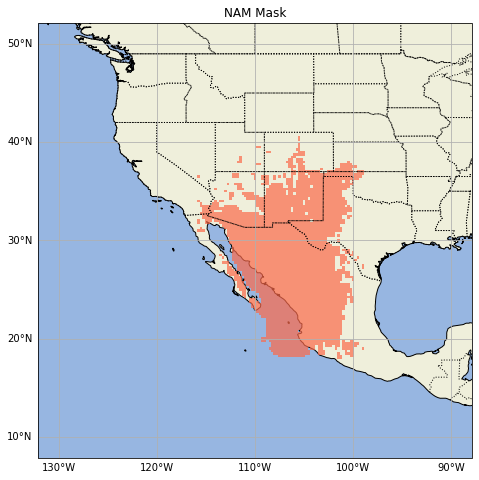

In [30]:
if __name__ == '__main__':
    # NAM_mask = main_mask(define_by='tp', months=[6, 7, 8, 9], threshold=1)
    # plot_NAM_mask(NAM_mask)

    # NAM_mask = main_mask(define_by='tcw', months=[6, 7, 8, 9], threshold=2)
    # plot_NAM_mask(NAM_mask)

    NAM_mask = main_mask(define_by='ROBUST')
    # NAM_mask.rename('NAM_mask').to_netcdf(os.path.join(my_era5_path, 'WestUS_Mexico', 'NAM_mask.nc'))
    plot_NAM_mask(NAM_mask)

In [ ]:
# # test cell
# var1 = 'cp'
# var2 = 'lsp'
# da1 = get_var_data(var1, level=500)
# da2 = get_var_data(var2, level=500)
# da_summer = da1.sel(time=da1['time.month'].isin([6, 7, 8, 9])).groupby('time.year').sum('time', skipna=True).mean('year', skipna=True)
# da_winter = da2.groupby('time.year').sum('time', skipna=True).mean('year', skipna=True)
# da_sub = da_summer / da_winter

# plot_da = xr.DataArray(da_sub > 1, dims=['latitude', 'longitude'])
# title = f'cp / lsp'

# vmin=0
# vmax=2
# levels=np.arange(vmin,vmax+.01, .01)
# norm=plt.Normalize(vmin,vmax)

# fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
# # add background features
# ax.add_feature(cfeature.LAND, color='lightgreen', alpha=0.5)
# ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.5)
# ax.add_feature(cfeature.COASTLINE, edgecolor='black')
# ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
# ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
# # plot data
# cf = ax.contourf(plot_da.longitude, plot_da.latitude, plot_da, levels=levels, norm=norm,
#                  cmap='turbo', extend='both', transform=ccrs.PlateCarree())
# cbar = plt.colorbar(cf, ax=ax, label=var_units[var], orientation='horizontal', pad=0.02)
# # add lat/lon grid
# gl = ax.gridlines(draw_labels=True)
# gl.top_labels = False
# gl.right_labels = False
# # set title and show
# ax.set_title(f'{title}')
# plt.show()

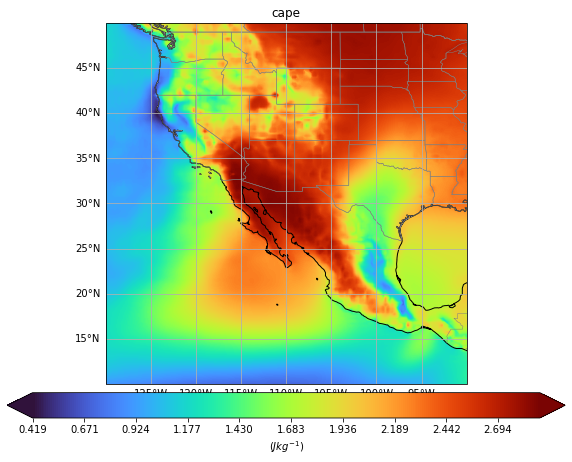

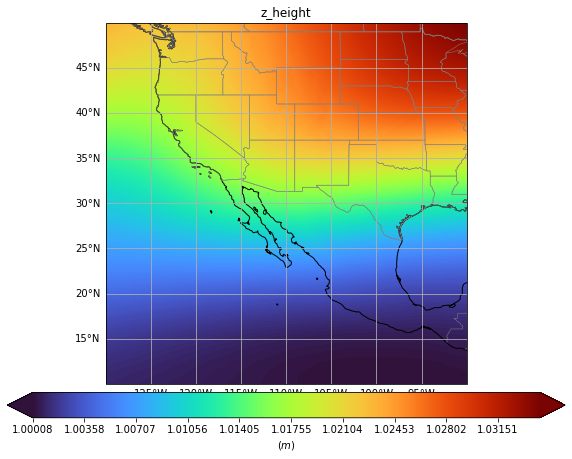

In [23]:
# test cell
var_list = [
    # 'tp',
    # 'cp',
    # 'tcw',
    'cape',
    'z_height',
    # 'viwve',
    # 'viwvn',
]

for var in var_list:
    da = get_var_data(var, level=500)
    da_summer = da.sel(time=da['time.month'].isin([6, 7, 8, 9])).mean('time', skipna=True)
    # da_winter = da.sel(time=da['time.month'].isin([1, 2, 3, 12])).mean('time', skipna=True)
    da_winter = da.mean('time', skipna=True)
    da_sub = da_summer / da_winter
    vmin = da_sub.min(skipna=True).values
    vmax = da_sub.max(skipna=True).values
    # vmin=1
    # vmax=2
    levels=np.linspace(vmin,vmax, 256)
    norm=plt.Normalize(vmin,vmax)
    
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    # add background features
    ax.add_feature(cfeature.LAND, color='lightgreen', alpha=0.5)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.5)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
    # plot data
    cf = ax.contourf(da_sub.longitude, da_sub.latitude, da_sub, levels=levels, norm=norm,
                     cmap='turbo', extend='both', transform=ccrs.PlateCarree())
    cbar = plt.colorbar(cf, ax=ax, label=var_units[var], orientation='horizontal', pad=0.02)
    # add lat/lon grid
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    # set title and show
    ax.set_title(f'{var}')
    plt.show()